### Debuging TIE Software

Debugging of calculation class

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from daten import file
import tifffile as tif
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import calculation_utils as calc_utils
from tie_admm import TIE_ADMM


## Initializing File & Importing Data

In [2]:
file.reset()

path_stk = r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\2025-05-02\cheek-01\TIE.tif"
path_bgd = r"C:\Users\q082fh\Documents\TIE\Measurements\Measurements with DHM\2025-05-02\cheek-04\TIE-BG.tif"

In [3]:
file.sample = tif.imread(path_stk)
file.background = tif.imread(path_bgd)
file.stack = file.sample / file.background
file.x1, file.x2 = 0, file.sample.shape[2]
file.y1, file.y2 = 0, file.sample.shape[1]
file.idx_focused_image = 10
file.axial_separation = 1

## FFT

In [4]:
def calculate_opl_fft_new(low=True, high =False, statistics=False): 
    if not statistics:  
       calc_utils.extract_roi()
        # find_focused_image_FOV(file)

    # Calculation of axial intensity derivative    
    I1, dI = calc_utils.compute_intensity_derivative()
    _, _, kernel = calc_utils.compute_fft_meshgrid()
    
    F_Psi = fft2(-dI)*kernel
    Psi = ifft2(F_Psi).real

    gx, gy = np.gradient(Psi)
    tmp = (np.gradient(gx/I1)[0] + np.gradient(gy/I1)[1])/file.pixel_size**2  #divide by ux**2 to account for the units!
    
    # solving the laplace equation via FFT
    F_OPL = fft2(tmp)*kernel
    OPL = ifft2(F_OPL).real * 1e9 # to convert to nm
    OPL -= np.min(OPL)

    file.opd = OPL  
    file.calculation_option="FFT"      
    return OPL


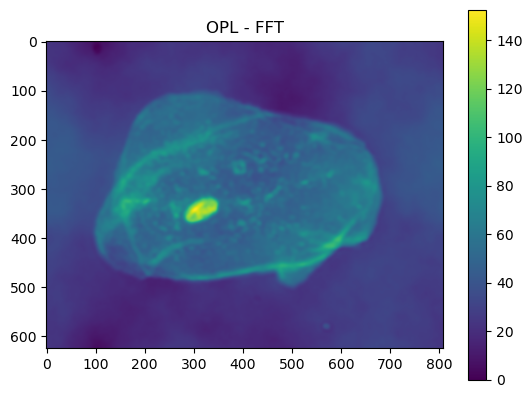

In [5]:
OPL_FFT = (calculate_opl_fft_new(low=True, high =False, statistics=False))

plt.imshow(OPL_FFT)
plt.title("OPL - FFT")
plt.colorbar()


## US - Method

In [6]:
def calculate_opl_US_method_new(statistics=False):
    def calc_phase(dI, I_max, k0, kernel):
        F_psi = -fft2(dI)*kernel*k0
        return ifft2(F_psi).real/I_max
    
    def calc_dI(psi, Kx, Ky, I0, k0):
        gx = ifft2(1j*Kx*fft2(psi)).real*I0
        gy = ifft2(1j*Ky*fft2(psi)).real*I0
        J = (ifft2(1j*Kx*fft2(gx))+ifft2(1j*Ky*fft2(gy))).real/k0
        return -J

    if not statistics: calc_utils.extract_roi()
        # find_focused_image_FOV(file)

    I_max = np.max(file.selected_stack[file.idx_focused_image])
    I1, dI = calc_utils.compute_intensity_derivative()
    I1 = ifftshift(I1)
    dI = ifftshift(dI)

    Kx, Ky, kernel = calc_utils.compute_fft_meshgrid()
    k0 = 2 * np.pi/(550*1e-9)
    
    dI0 = dI.copy()
    psi0 = 0

    for i in range(50):
        psi1 = calc_phase(dI0, I_max, k0, kernel)
        dI1 = calc_dI(psi1,Kx,Ky,I1, k0)
        dI0 = dI0 - dI1
        psi0 = psi0 + psi1

    OPL = fftshift(psi0).real*100

    file.opd = OPL
    file.calculation_option="US_method"
    return OPL

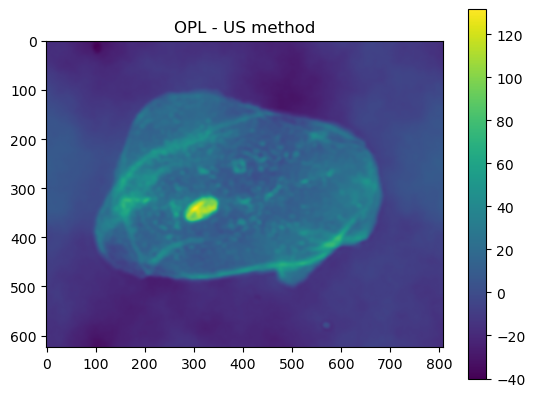

In [7]:
OPL_US = (calculate_opl_US_method_new(statistics=False))

plt.imshow(OPL_US)
plt.title("OPL - US method")
plt.colorbar()

## Mixing - Method

In [8]:
def mixing_new(statistic=False):
    sigma=1
    OPL_lo=calculate_opl_fft_new(low=True, high=False, statistics=statistic)

    file.mixing_high = True
    OPL_hi=calculate_opl_fft_new(low=False, high=True, statistics=statistic)
    file.mixing_high = False

    gaussian2D = lambda x, y, sigma: np.exp(-((x)**2/(2*sigma**2) + (y)**2/(2*sigma**2)))
    Kx, Ky, _ = calc_utils.compute_fft_meshgrid()
    
    LP_filt = ifftshift(gaussian2D(Kx,Ky,sigma))
       
    F_hi = fft2(OPL_hi)
    F_lo = fft2(OPL_lo)
    F_mix = LP_filt * F_lo + (1-LP_filt) * F_hi
    OPL = np.real(ifft2(F_mix))
    file.opd = OPL
    file.calculation_option="mixing"
    return OPL

False


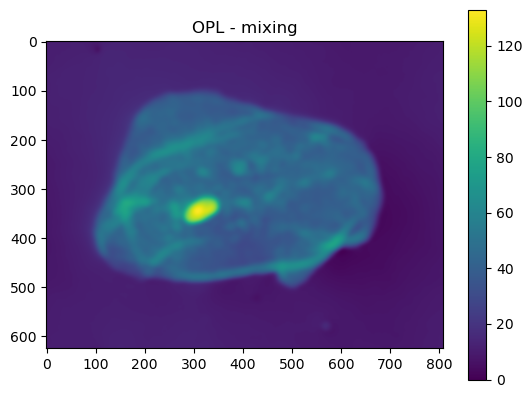

In [9]:
file.axial_separation_high = 9
file.mixing_high = True
OPL_mixing = (mixing_new(statistic=False))
plt.imshow(OPL_mixing)
plt.title("OPL - mixing")
plt.colorbar()
print(file.mixing_high)

## TV - Regularization - Method

In [14]:
def calculate_opl_tv_new(statistics=False):
    if not statistics: calc_utils.extract_roi()
        # find_focused_image_FOV(file)

    _ , nx , ny = file.selected_stack.shape
    _ , dI = calc_utils.compute_intensity_derivative()
    dI = -dI*file.axial_step

    tm = TIE_ADMM(nx,ny)
    result = tm.solve_tie(dI, maxiter=file.iteration, lambda_tv=file.lbda_TV)
    OPL=result*file.axial_step/file.pixel_size
    OPL = np.array(OPL, dtype=np.float32)
    file.opd= OPL 
    file.calculation_option="TvNorm"

    return OPL

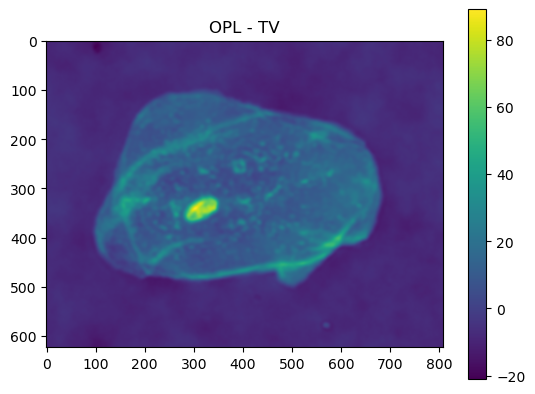

In [15]:
OPL = calculate_opl_tv_new()

plt.imshow(OPL)
plt.title("OPL - TV")
plt.colorbar()